# Ablation Skip-Connections (TransUNet) — `huong3.ipynb`

**Mục tiêu:** Chứng minh vai trò skip-connection (Figure 2, TransUNet paper) — **vẫn xoay quanh TransUNet**.

| `n_skip` | Tên | Ý nghĩa |
|----------|-----|---------|
| **0** | R50-ViT-CUP | Không skip — Transformer + decoder thuần |
| **1** | TransUNet (1 skip) | Một nhánh skip |
| **3** | TransUNet đầy đủ | Đã có trong `demo.ipynb` — **không train lại** |

**Deadline gấp:** mặc định `MAX_EPOCHS = 60` (~27 phút/epoch). Xu hướng 0 < 1 < 3 thường vẫn đúng; nếu còn thời gian đổi thành `150` cho sát paper.

**Chạy trên Colab:** Runtime → GPU → **Run All** (hoặc từng section).

**Thời gian ước tính (60 epoch):** train 0-skip ~27p + test ~24p + train 1-skip ~27p + test ~24p ≈ **~1.7 giờ**.

In [1]:
# ========== CAU HINH (sua o day neu can) ==========
MAX_EPOCHS = 60          # 60 = nhanh (deadline); 150 = sat paper/demo
BATCH_SIZE = 24
BASE_LR = 0.01
VIT_NAME = 'R50-ViT-B_16'

# === 1. INSTALL ===
!pip install -q ml-collections medpy SimpleITK tensorboardX h5py scipy matplotlib kaggle

# === 2. CLONE REPO ===
!rm -rf /content/TransUNet
!git clone https://github.com/Beckschen/TransUNet.git

# === 3. KAGGLE ===
import os, shutil
os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
with open(os.path.expanduser('~/.kaggle/kaggle.json'), 'wb') as f:
    f.write(b'{"username":"ynzboyvt","key":"KGAT_e1129cdba4fc46f3eb3dfdfb0c7b7f9a"}')
os.chmod(os.path.expanduser('~/.kaggle/kaggle.json'), 0o600)

# === 4-6. DATA ===
!kaggle datasets download -d dogcdt/synapse -p /content/synapse_zip
!unzip -q -o /content/synapse_zip/*.zip -d /content/synapse_temp
for folder in ['train_npz', 'test_vol_h5']:
    src = f'/content/synapse_temp/Synapse/{folder}'
    dst = f'/content/data/Synapse/{folder}'
    os.makedirs(dst, exist_ok=True)
    for fname in os.listdir(src):
        shutil.move(os.path.join(src, fname), os.path.join(dst, fname))
!rm -rf /content/synapse_zip /content/synapse_temp

# === 7. VIT WEIGHTS ===
os.makedirs('/content/model/vit_checkpoint/imagenet21k', exist_ok=True)
!wget -q https://storage.googleapis.com/vit_models/imagenet21k/R50+ViT-B_16.npz \
    -O /content/model/vit_checkpoint/imagenet21k/R50+ViT-B_16.npz

# === 8. FIX CONFIG PATH ===
cfg = '/content/TransUNet/networks/vit_seg_configs.py'
with open(cfg, 'r') as f: txt = f.read()
txt = txt.replace("'../model/vit_checkpoint/imagenet21k/", "'/content/model/vit_checkpoint/imagenet21k/")
with open(cfg, 'w') as f: f.write(txt)

t = len(os.listdir('/content/data/Synapse/train_npz'))
e = len(os.listdir('/content/data/Synapse/test_vol_h5'))
gpu = !nvidia-smi --query-gpu=name --format=csv,noheader
print(f"GPU: {gpu[0] if gpu else 'NONE!'}")
print(f"Train slices: {t} | Test volumes: {e}")
print(f"MAX_EPOCHS={MAX_EPOCHS} | ~{MAX_EPOCHS*0.45:.0f} phut train / run (uoc tinh)")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.3/156.3 kB 14.9 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.7/76.7 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 50.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 9.8 MB/s eta 0:00:00
Cloning into 'TransUNet'...
remote: Enumerating objects: 128, done.
remote: Counting objects: 100% (88/88), done.
remote: Compressing objects: 100% (40/40), done.
remote: Total 128 (delta 71), reused 48 (delta 48), pack-reused 40 (from 1)
Receiving objects: 100% (128/128), 47.00 KiB | 9.40 MiB/s, done.
Resolving deltas: 100% (71/71), done.
Dataset URL: https://www.kaggle.com/datasets/dogcdt/synapse
License(s): unknown
100% 607M/607M [00:35<00:00, 17.7MB/s]

GPU: NVIDIA A100-SXM4-80GB
Train slices: 2211 | Test volumes: 12
MAX_EPOCHS=60 | ~27 phut train / run (uoc tinh)


In [2]:
%cd /content/TransUNet
!touch datasets/__init__.py networks/__init__.py
!python -c "from datasets.dataset_synapse import Synapse_dataset; print('Import OK!')"

config_file = '/content/TransUNet/networks/vit_seg_configs.py'
with open(config_file, 'r') as f: txt = f.read()
txt = txt.replace("'../model/vit_checkpoint/imagenet21k/", "'/content/model/vit_checkpoint/imagenet21k/")
with open(config_file, 'w') as f: f.write(txt)
print('Config OK')

/content/TransUNet
Import OK!
Config OK


## 1. Train + Test — `n_skip = 0` (R50-ViT-CUP)

Không có skip từ ResNet → DSC/HD95 kỳ vọng **tệ nhất** trong 3 cấu hình.

In [3]:
# Chay cell SETUP truoc (co MAX_EPOCHS, BATCH_SIZE, BASE_LR)
import subprocess, os
os.chdir('/content/TransUNet')
subprocess.run([
    'python', 'train.py',
    '--dataset', 'Synapse', '--vit_name', 'R50-ViT-B_16',
    '--root_path', '/content/data/Synapse/train_npz',
    '--list_dir', './lists/lists_Synapse', '--num_classes', '9',
    '--n_skip', '0', '--max_epochs', str(MAX_EPOCHS),
    '--batch_size', str(BATCH_SIZE), '--base_lr', str(BASE_LR),
], check=True)

CompletedProcess(args=['python', 'train.py', '--dataset', 'Synapse', '--vit_name', 'R50-ViT-B_16', '--root_path', '/content/data/Synapse/train_npz', '--list_dir', './lists/lists_Synapse', '--num_classes', '9', '--n_skip', '0', '--max_epochs', '60', '--batch_size', '24', '--base_lr', '0.01'], returncode=0)

In [4]:
import subprocess, os
os.chdir('/content/TransUNet')
subprocess.run([
    'python', 'test.py',
    '--dataset', 'Synapse', '--vit_name', 'R50-ViT-B_16',
    '--volume_path', '/content/data/Synapse/test_vol_h5',
    '--list_dir', './lists/lists_Synapse', '--num_classes', '9',
    '--n_skip', '0', '--max_epochs', str(MAX_EPOCHS),
    '--batch_size', str(BATCH_SIZE), '--base_lr', str(BASE_LR),
], check=True)

CompletedProcess(args=['python', 'test.py', '--dataset', 'Synapse', '--vit_name', 'R50-ViT-B_16', '--volume_path', '/content/data/Synapse/test_vol_h5', '--list_dir', './lists/lists_Synapse', '--num_classes', '9', '--n_skip', '0', '--max_epochs', '60', '--batch_size', '24', '--base_lr', '0.01'], returncode=0)

## 2. Train + Test — `n_skip = 1`

In [5]:
import subprocess, os
os.chdir('/content/TransUNet')
subprocess.run([
    'python', 'train.py',
    '--dataset', 'Synapse', '--vit_name', 'R50-ViT-B_16',
    '--root_path', '/content/data/Synapse/train_npz',
    '--list_dir', './lists/lists_Synapse', '--num_classes', '9',
    '--n_skip', '1', '--max_epochs', str(MAX_EPOCHS),
    '--batch_size', str(BATCH_SIZE), '--base_lr', str(BASE_LR),
], check=True)

CompletedProcess(args=['python', 'train.py', '--dataset', 'Synapse', '--vit_name', 'R50-ViT-B_16', '--root_path', '/content/data/Synapse/train_npz', '--list_dir', './lists/lists_Synapse', '--num_classes', '9', '--n_skip', '1', '--max_epochs', '60', '--batch_size', '24', '--base_lr', '0.01'], returncode=0)

In [6]:
import subprocess, os
os.chdir('/content/TransUNet')
subprocess.run([
    'python', 'test.py',
    '--dataset', 'Synapse', '--vit_name', 'R50-ViT-B_16',
    '--volume_path', '/content/data/Synapse/test_vol_h5',
    '--list_dir', './lists/lists_Synapse', '--num_classes', '9',
    '--n_skip', '1', '--max_epochs', str(MAX_EPOCHS),
    '--batch_size', str(BATCH_SIZE), '--base_lr', str(BASE_LR),
], check=True)

CompletedProcess(args=['python', 'test.py', '--dataset', 'Synapse', '--vit_name', 'R50-ViT-B_16', '--volume_path', '/content/data/Synapse/test_vol_h5', '--list_dir', './lists/lists_Synapse', '--num_classes', '9', '--n_skip', '1', '--max_epochs', '60', '--batch_size', '24', '--base_lr', '0.01'], returncode=0)

## 3. Bảng tổng hợp + biểu đồ

Tự đọc log test vừa chạy. Số **3-skip** và **U-Net** lấy từ `demo.ipynb` (không train lại).
Số **paper** (Table 1) để tham chiếu.

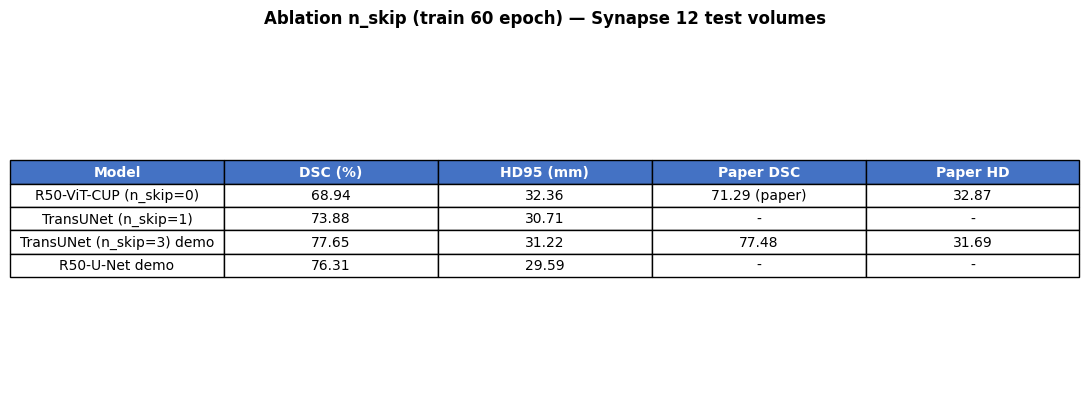

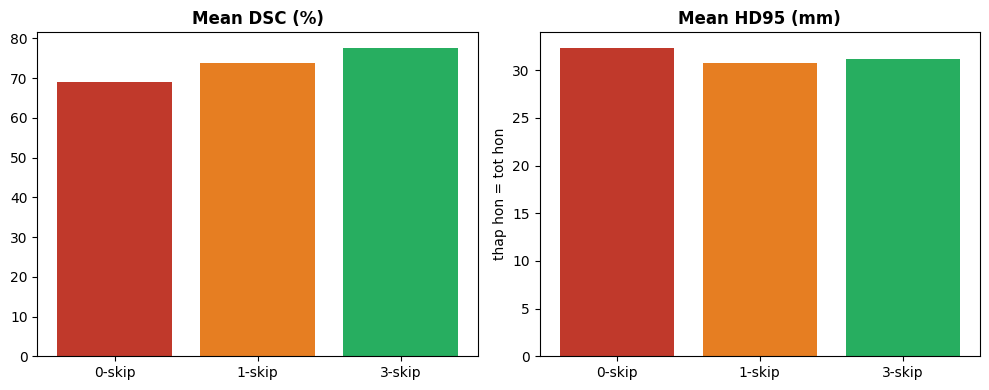

TOM TAT (dien tay neu parse log that bai):
  n_skip=0: DSC=68.9436  HD95=32.357463
  n_skip=1: DSC=73.8828  HD95=30.714001
  n_skip=3 (demo): DSC=77.65%  HD95=31.22
Log test: ['/content/TransUNet/test_log/test_log_TU_Synapse224/TU_pretrain_R50-ViT-B_16_skip0_epo60_bs24_224.txt', '/content/TransUNet/test_log/test_log_TU_Synapse224/TU_pretrain_R50-ViT-B_16_skip1_epo60_bs24_224.txt']


In [7]:
import os, re, glob
import numpy as np
import matplotlib.pyplot as plt

# MAX_EPOCHS, BATCH_SIZE tu cell SETUP dau tien

def snapshot_dir(n_skip):
    return f'/content/model/TU_Synapse224/TU_pretrain_R50-ViT-B_16_skip{n_skip}_epo{MAX_EPOCHS}_bs24_224'

def parse_test_log(n_skip):
    log_dir = '/content/TransUNet/test_log'
    pat = f'*skip{n_skip}*'
    files = []
    for root, dirs, fnames in os.walk(log_dir):
        for fn in fnames:
            if fn.endswith('.txt') and f'skip{n_skip}' in root + fn:
                files.append(os.path.join(root, fn))
    if not files:
        files = glob.glob(f'{log_dir}/**/*skip{n_skip}*.txt', recursive=True)
    if not files:
        return None, None
    path = sorted(files, key=os.path.getmtime)[-1]
    text = open(path).read()
    m = re.search(r'mean_dice\s*:\s*([\d.]+)\s*mean_hd95\s*:\s*([\d.]+)', text)
    if m:
        return float(m.group(1)) * 100, float(m.group(2))
    return None, None

# --- Ket qua ablation vua chay ---
d0, h0 = parse_test_log(0)
d1, h1 = parse_test_log(1)

# --- Tu demo.ipynb (3-skip + U-Net) ---
d3, h3 = 77.65, 31.22      # TransUNet n_skip=3
d_un, h_un = 76.31, 29.59  # R50-U-Net

# --- Paper Table 1 (tham chieu) ---
d_p0, h_p0 = 71.29, 32.87  # R50-ViT-CUP ~ n_skip=0

rows = [
    ['R50-ViT-CUP (n_skip=0)', f'{d0:.2f}' if d0 else 'chay test tren', f'{h0:.2f}' if h0 else '-', f'{d_p0:.2f} (paper)', f'{h_p0:.2f}'],
    ['TransUNet (n_skip=1)', f'{d1:.2f}' if d1 else '-', f'{h1:.2f}' if h1 else '-', '-', '-'],
    ['TransUNet (n_skip=3) demo', f'{d3:.2f}', f'{h3:.2f}', '77.48', '31.69'],
    ['R50-U-Net demo', f'{d_un:.2f}', f'{h_un:.2f}', '-', '-'],
]

os.makedirs('/content/huong3_output', exist_ok=True)
fig, ax = plt.subplots(figsize=(12, 4.5)); ax.axis('off')
cols = ['Model', 'DSC (%)', 'HD95 (mm)', 'Paper DSC', 'Paper HD']
tbl = ax.table(cellText=rows, colLabels=cols, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(10); tbl.scale(1.15, 1.4)
for j in range(len(cols)):
    tbl[0, j].set_facecolor('#4472C4'); tbl[0, j].set_text_props(color='white', fontweight='bold')
ax.set_title(f'Ablation n_skip (train {MAX_EPOCHS} epoch) — Synapse 12 test volumes',
             fontsize=12, fontweight='bold', pad=16)
plt.savefig('/content/huong3_output/ablation_table.png', dpi=150, bbox_inches='tight')
plt.show()

# Bieu do DSC
labels, dscs, valid = [], [], []
for lab, d in [('0-skip', d0), ('1-skip', d1), ('3-skip', d3)]:
    if d is not None:
        labels.append(lab); dscs.append(d); valid.append(True)
    else:
        labels.append(lab); dscs.append(0); valid.append(False)

if any(valid):
    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    x = np.arange(len(labels))
    colors = ['#c0392b', '#e67e22', '#27ae60']
    for ax, vals, title, ylab in zip(axes,
        [[d0, d1, d3], [h0, h1, h3]],
        ['Mean DSC (%)', 'Mean HD95 (mm)'],
        ['DSC', 'HD95']):
        v = [a if a is not None else 0 for a in vals]
        m = [a is not None for a in vals]
        bars = ax.bar(x, v, color=colors)
        for i, (b, ok) in enumerate(zip(bars, m)):
            if not ok: b.set_alpha(0.3)
        ax.set_xticks(x); ax.set_xticklabels(labels)
        ax.set_title(title, fontweight='bold')
        if ylab == 'HD95': ax.set_ylabel('thap hon = tot hon')
    plt.tight_layout()
    plt.savefig('/content/huong3_output/ablation_bars.png', dpi=150, bbox_inches='tight')
    plt.show()

print('='*60)
print('TOM TAT (dien tay neu parse log that bai):')
print(f'  n_skip=0: DSC={d0}  HD95={h0}')
print(f'  n_skip=1: DSC={d1}  HD95={h1}')
print(f'  n_skip=3 (demo): DSC={d3}%  HD95={h3}')
print('='*60)
print('Log test:', glob.glob('/content/TransUNet/test_log/**/*.txt', recursive=True)[:5])

In [8]:
!zip -r /content/huong3_output.zip /content/huong3_output/ 2>/dev/null || true
try:
    from google.colab import files
    files.download('/content/huong3_output.zip')
except Exception:
    print('Chay tren Colab de tai zip; hoac xem /content/huong3_output/')

  adding: content/huong3_output/ (stored 0%)
  adding: content/huong3_output/ablation_table.png (deflated 17%)
  adding: content/huong3_output/ablation_bars.png (deflated 24%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>